<a href="https://colab.research.google.com/github/JanuNandhini/24ADI003-ex-7-24BAD041/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


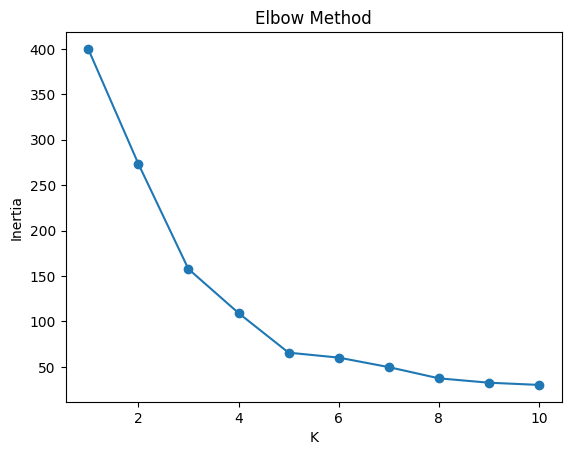

K-Means Silhouette Score: 0.5546571631111091


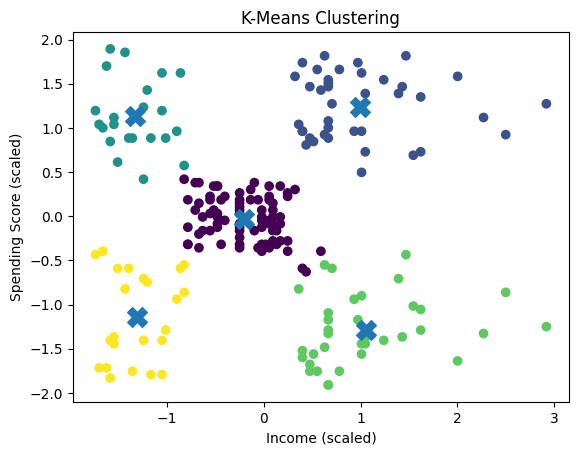


Cluster Means:

                Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                            
0                        55.296296               49.518519
1                        86.538462               82.128205
2                        25.727273               79.363636
3                        88.200000               17.114286
4                        26.304348               20.913043


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("/content/Mall_Customers.csv")

print(df.isnull().sum())

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels
print("K-Means Silhouette Score:",
      silhouette_score(X_scaled, kmeans_labels))

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clustering")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print("\nCluster Means:\n")
print(df.groupby('KMeans_Cluster')[['Annual Income (k$)',
                                   'Spending Score (1-100)']].mean())